# Phase 3: Behavioral Analysis(by GraphFrames)

### I. Overview

This notebook applies **Graph Analytics using PySpark and GraphFrames** to large-scale credit card transaction data to uncover complex financial fraud patterns, risk propagation chains, and organized crime rings.

**Key Points:**
1. Graph Construction: Bipartite network model connecting Customer nodes (`C_xxxx`) and POS Terminal nodes (`T_xxxx`) via directed transaction edges.
2. Degree Analytics & Anomaly Detection: Evaluating POS In-Degree and Customer Out-Degree using $3\sigma$ Z-score statistical thresholds to locate abnormal hubs.
3. Cross-Infection Motif Analysis: Discovering structural infection chains ($A \rightarrow T1 \leftarrow B \rightarrow T2$) to isolate compromised POS terminals.
4. Risk Contagion Tracing (BFS): Breadth-First Search (4-hop radius) starting from fraudulent accounts to proactively identify indirect victim accounts.
5. Organized Fraud Ring Discovery (LPA): Community Detection via Label Propagation Algorithm to uncover hidden organized fraud rings.


### II. Graph Construction

- Initialize Spark Sessions with GraphFrames and Hive

In [1]:
!pip install networkx matplotlib

In [1]:
import warnings
import logging

# 1. Suppress Python warnings
warnings.filterwarnings('ignore')

# 2. Suppress PySpark logs (if using Spark)
if 'spark' in globals():
    spark.sparkContext.setLogLevel("ERROR")
logging.getLogger("py4j").setLevel(logging.ERROR)


In [2]:
import os, sys
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lit, concat

spark = SparkSession.builder \
    .appName("Credit_Card_Fraud_Graph_Processing") \
    .config("spark.jars.packages", "graphframes:graphframes:0.8.2-spark3.2-s_2.12") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("hive.metastore.uris", "thrift://hive-metastore:9083") \
    .config("spark.sql.warehouse.dir", "hdfs://namenode:9000/user/hive/warehouse") \
    .enableHiveSupport() \
    .getOrCreate()



- Get data from Hive (or HDFS)

In [3]:
# Read data from Hive table (assuming table name is 'credit_transaction_db.cleaned_transactions')
# Or read directly from Parquet directory on HDFS
spark.sql("USE credit_transaction_db")
df = spark.table("cleaned_transactions")

# Display Schema and record count for verification
df.printSchema()
print(f"Total transactions: {df.count():,}")

root
 |-- TRANSACTION_ID: long (nullable = true)
 |-- TX_DATETIME: timestamp (nullable = true)
 |-- CUSTOMER_ID: long (nullable = true)
 |-- TERMINAL_ID: long (nullable = true)
 |-- TX_AMOUNT: double (nullable = true)
 |-- TX_TIME_SECONDS: long (nullable = true)
 |-- TX_TIME_DAYS: integer (nullable = true)
 |-- TX_FRAUD: integer (nullable = true)
 |-- TX_FRAUD_SCENARIO: integer (nullable = true)
 |-- tx_date: date (nullable = true)
 |-- tx_hour: integer (nullable = true)
 |-- tx_day_of_week: string (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- is_night: integer (nullable = true)
 |-- customer_tx_count: long (nullable = true)
 |-- customer_avg_amount: double (nullable = true)
 |-- terminal_tx_count: long (nullable = true)
 |-- tx_year_month: string (nullable = true)

Total transactions: 14,158,985


- Define Vertices
The vertice represents customer or POS device inside the transaction.

In [5]:
from pyspark.sql.functions import concat

# Add prefix C_ for Customers
customers = df.select(concat(lit("C_"), col("CUSTOMER_ID").cast("string")).alias("id")) \
              .distinct() \
              .withColumn("type", lit("Customer"))

# Add prefix T_ for Terminals
terminals = df.select(concat(lit("T_"), col("TERMINAL_ID").cast("string")).alias("id")) \
              .distinct() \
              .withColumn("type", lit("Terminal"))

# Combine into a single Vertices table
vertices = customers.union(terminals)

print(f"Total Vertices: {vertices.count():,}")
vertices.show(5)

Total Vertices: 109,997
+------+--------+
|    id|    type|
+------+--------+
|C_4756|Customer|
|C_3628|Customer|
|C_4672|Customer|
|C_2605|Customer|
|C_5013|Customer|
+------+--------+
only showing top 5 rows



- Define Edges

In [6]:
# Update source and destination IDs to match the new Vertices format
edges = df.withColumn("src", concat(lit("C_"), col("CUSTOMER_ID").cast("string"))) \
          .withColumn("dst", concat(lit("T_"), col("TERMINAL_ID").cast("string")))

# Remaining columns (TX_DATETIME, TX_AMOUNT, TX_FRAUD...) automatically become Edge attributes
print(f"Total Edges: {edges.count():,}")
edges.show(5)

Total Edges: 14,158,985
+--------------+-------------------+-----------+-----------+---------+---------------+------------+--------+-----------------+----------+-------+--------------+----------+--------+-----------------+-------------------+-----------------+-------------+------+-------+
|TRANSACTION_ID|        TX_DATETIME|CUSTOMER_ID|TERMINAL_ID|TX_AMOUNT|TX_TIME_SECONDS|TX_TIME_DAYS|TX_FRAUD|TX_FRAUD_SCENARIO|   tx_date|tx_hour|tx_day_of_week|is_weekend|is_night|customer_tx_count|customer_avg_amount|terminal_tx_count|tx_year_month|   src|    dst|
+--------------+-------------------+-----------+-----------+---------+---------------+------------+--------+-----------------+----------+-------+--------------+----------+--------+-----------------+-------------------+-----------------+-------------+------+-------+
|       6724753|2019-03-13 14:49:57|       9661|      99899|     4.28|       29947797|         346|       0|                0|2019-03-13|     14|           Wed|         0|       

- Define Graph

In [7]:
import time
from pyspark.sql.functions import col, desc
from graphframes import GraphFrame

# Initialize Graph Network
g = GraphFrame(vertices, edges)

# Enable checkpoint directory (Required for heavy graph algorithms)
spark.sparkContext.setCheckpointDir("hdfs://namenode:9000/user/spark/checkpoints")

print(f"Number of Edges: {edges.count():,}")
print(f"Number of Vertices: {vertices.count():,}")

Number of Edges: 14,158,985
Number of Vertices: 109,997


### III. Degree Analytics

#### 3.1. POS statistics show a large volume of transaction connections (In-Degree)

In [17]:
# Use built-in inDegrees property of GraphFrames
gf_indegree = g.inDegrees

# Get Top 10 devices
gf_indegree = g.inDegrees \
    .filter(col("id").like("T_%")) \
    .orderBy(desc("inDegree"))

gf_result = gf_indegree.limit(10)

# Action: .show() triggers processing and prints results to screen
print("Top 10 POS terminals with highest incoming transaction volume:")
gf_result.show()


Top 10 POS terminals with highest incoming transaction volume:
+-------+--------+
|     id|inDegree|
+-------+--------+
|T_11678|     254|
|T_74295|     251|
|T_55218|     249|
|T_42247|     248|
|T_43006|     246|
|T_87849|     243|
|T_90425|     243|
| T_8453|     243|
|T_67034|     242|
|T_59139|     242|
+-------+--------+



- Visualize results (Bar Chart + Network Graph)

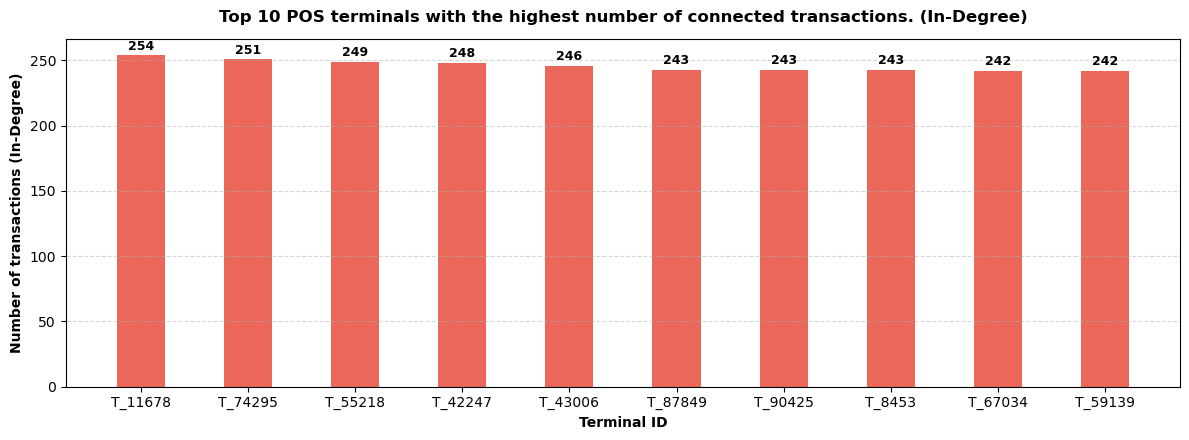

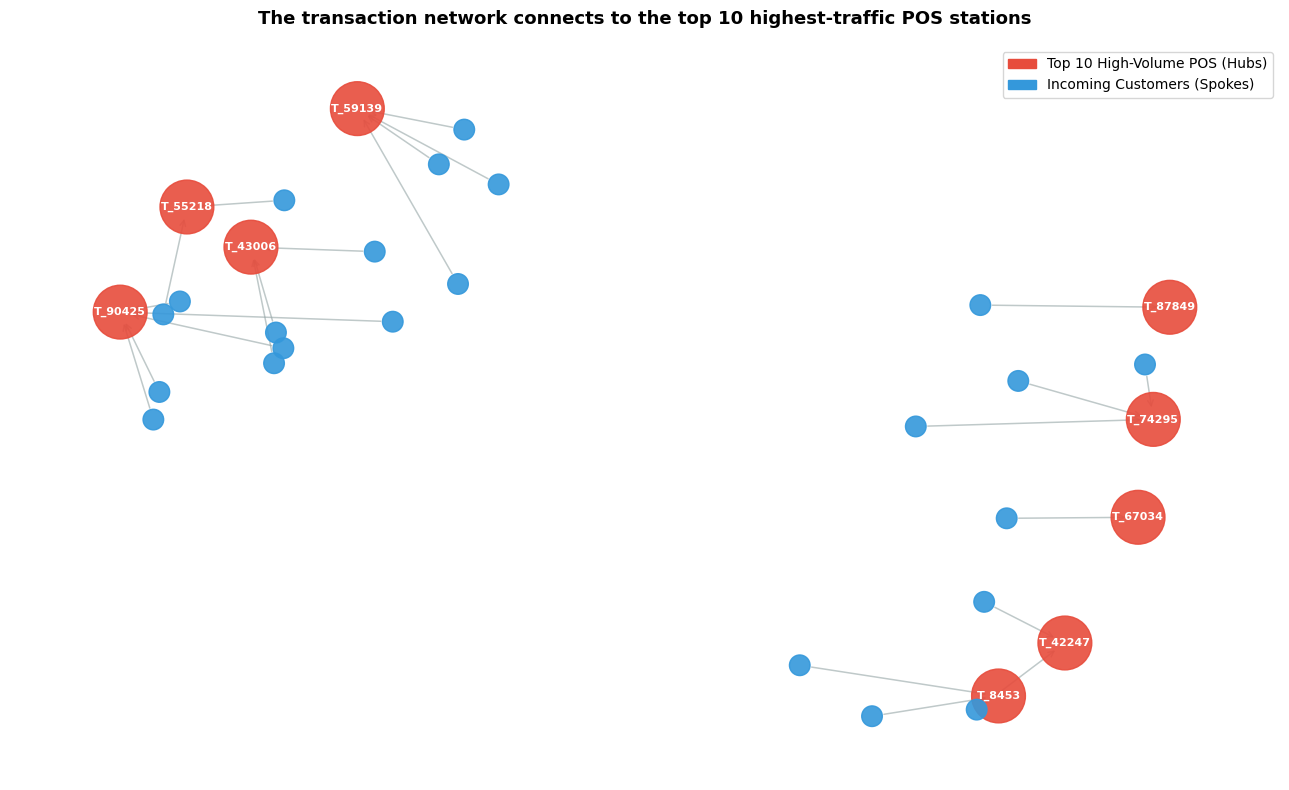

In [19]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pyspark.sql.functions import col, desc

# ---------------------------------------------------------
# Chart 1: The bar chart displays specific In-Degree numbers.
# ---------------------------------------------------------
top10_pd = gf_result.toPandas()

plt.figure(figsize=(12, 4.5))
bars = plt.bar(top10_pd['id'], top10_pd['inDegree'], color='#e74c3c', alpha=0.85, width=0.45)

# Add a number at the top of each column
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 2, f"{int(yval)}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Top 10 POS terminals with the highest number of connected transactions. (In-Degree)', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Terminal ID', fontweight='bold')
plt.ylabel('Number of transactions (In-Degree)', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Chart 2: Graph of Hub-and-Spoke Network Connecting Top 10 POSs
# ---------------------------------------------------------
top_10_pos_ids = top10_pd['id'].tolist()

# Sample representative transactions connected to the Top 10 POS terminals.
top_edges = edges.filter(col("dst").isin(top_10_pos_ids)) \
                 .select("src", "dst") \
                 .sample(withReplacement=False, fraction=0.01, seed=42) \
                 .limit(100) \
                 .collect()

G_top10 = nx.DiGraph()
for row in top_edges:
    G_top10.add_edge(row['src'], row['dst'])

node_colors = ['#e74c3c' if node in top_10_pos_ids else '#3498db' for node in G_top10.nodes()]
node_sizes = [1500 if node in top_10_pos_ids else 220 for node in G_top10.nodes()]

plt.figure(figsize=(13, 8))
pos = nx.spring_layout(G_top10, seed=42, k=0.35)

nx.draw_networkx_nodes(G_top10, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_edges(G_top10, pos, arrowstyle='->', arrowsize=10, edge_color='#95a5a6', alpha=0.6, width=1.1)

pos_labels = {n: n for n in G_top10.nodes() if n in top_10_pos_ids}
nx.draw_networkx_labels(G_top10, pos, labels=pos_labels, font_size=8, font_weight='bold', font_color='white')

pos_patch = mpatches.Patch(color='#e74c3c', label='Top 10 High-Volume POS (Hubs)')
cust_patch = mpatches.Patch(color='#3498db', label='Incoming Customers (Spokes)')
plt.legend(handles=[pos_patch, cust_patch], loc='upper right', fontsize=10)

plt.title('The transaction network connects to the top 10 highest-traffic POS stations', fontsize=13, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()


#### 3.2. Detecting customers with an unusual number of connections (Out-Degree & Z-Score > 3σ)

In [20]:
from pyspark.sql.functions import col, count, countDistinct, sum as _sum, round as _round, mean, stddev, desc

# ---------------------------------------------------------
# Step 1: Count the number of connections and the number of distinct POS terminals for each customer (Out-Degree)
# ---------------------------------------------------------
customer_conn_df = g.edges \
    .filter(col("src").like("C_%")) \
    .groupBy("src") \
    .agg(
        count("TRANSACTION_ID").alias("total_transactions"),        # Total number of transactions (Out-Degree)
        countDistinct("dst").alias("distinct_pos_count"),            # Number of connected distinct POS stations
        _sum("TX_AMOUNT").alias("total_amount"),                    # Total transaction amount
        _sum("TX_FRAUD").alias("fraud_tx_count")                    # Number of fraudulent transactions
    )

# ---------------------------------------------------------
# Step 2: Calculate the Statistical Abnormality Threshold (Z-Score > 3)
# ---------------------------------------------------------
stats = customer_conn_df.select(
    mean("distinct_pos_count").alias("avg_pos"),
    stddev("distinct_pos_count").alias("std_pos"),
    mean("total_transactions").alias("avg_tx"),
    stddev("total_transactions").alias("std_tx")
).first()

avg_pos, std_pos = stats["avg_pos"], stats["std_pos"]
avg_tx, std_tx = stats["avg_tx"], stats["std_tx"]

# 3-Sigma threshold (Only 0.15% of the most extreme data sets surpass this threshold)
threshold_pos = avg_pos + 3 * std_pos
threshold_tx = avg_tx + 3 * std_tx

print(f"📊 Average POS/Customer: {avg_pos:.2f} (Standard deviation σ: {std_pos:.2f})")
print(f"🚨 Abnormal POS connection threshold (> 3σ): {threshold_pos:.2f} POS\n")

# ---------------------------------------------------------
# Step 3: Filter the list of customers with unusual connections (Outliers).
# ---------------------------------------------------------
abnormal_customers_df = customer_conn_df.filter(
    (col("distinct_pos_count") > threshold_pos) | (col("total_transactions") > threshold_tx)
).withColumn(
    "z_score_pos", _round((col("distinct_pos_count") - avg_pos) / std_pos, 2)
).orderBy(desc("distinct_pos_count"), desc("z_score_pos"))

print("=== List of customers with unsual connection numbers (Z-SCORE > 3) ===")
abnormal_customers_df.show(15, truncate=False)


📊 Average POS/Customer: 555.46 (Standard deviation σ: 200.01)
🚨 Abnormal POS connection threshold (> 3σ): 1155.48 POS

=== List of customers with unsual connection numbers (Z-SCORE > 3) ===
+---+------------------+------------------+------------+--------------+-----------+
|src|total_transactions|distinct_pos_count|total_amount|fraud_tx_count|z_score_pos|
+---+------------------+------------------+------------+--------------+-----------+
+---+------------------+------------------+------------+--------------+-----------+



- Visualize results (Inline Histogram + KDE & Boxplot)

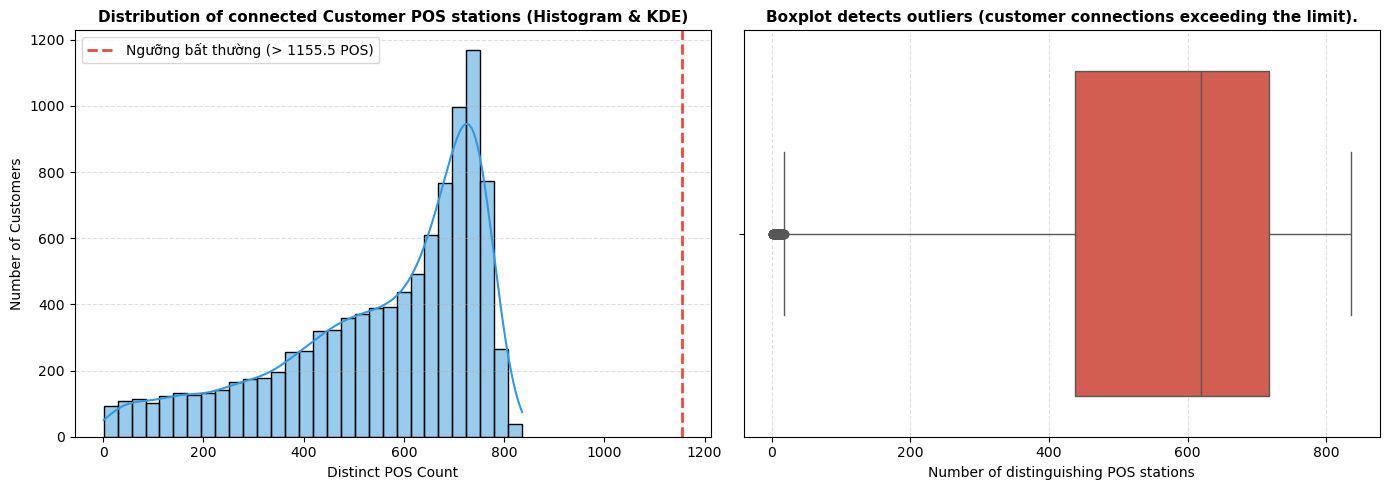

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert POS quantity statistics data to Pandas for visualization.
conn_pd = customer_conn_df.select("distinct_pos_count").toPandas()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Figure 1: Histogram + KDE showing the distribution and threshold line of 3-Sigma
sns.histplot(conn_pd['distinct_pos_count'], kde=True, ax=ax1, color='#3498db', bins=30)
ax1.axvline(threshold_pos, color='#e74c3c', linestyle='--', linewidth=2, label=f'Ngưỡng bất thường (> {threshold_pos:.1f} POS)')
ax1.set_title("Distribution of connected Customer POS stations (Histogram & KDE)", fontweight='bold', fontsize=11)
ax1.set_xlabel("Distinct POS Count")
ax1.set_ylabel("Number of Customers")
ax1.legend(fontsize=10)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# Figure 2: Boxplot detecting outliers
sns.boxplot(x=conn_pd['distinct_pos_count'], ax=ax2, color='#e74c3c')
ax2.set_title("Boxplot detects outliers (customer connections exceeding the limit).", fontweight='bold', fontsize=11)
ax2.set_xlabel("Number of distinguishing POS stations")
ax2.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


### IV. Detect the chain of Infection and Risky POS stations (Motif Pattern & Risk POS)

#### 4.1. Motif Finding: Find the risk transmission pattern (Fraud Customer -> POS T1 -> Victim -> POS T2)

In [22]:
from pyspark.sql.functions import col

print("=== FRAUDULENT INFECTION CHAIN ​​ANALYSIS (MOTIF FINDING) ===")

# Find the infection chain motif structure: (A scans T1) -> (B scans T1) -> (B scans T2)
motifs = g.find("(a)-[e1]->(t1); (b)-[e2]->(t1); (b)-[e3]->(t2)")

# Filtering by logical constraints & time series
gf_pattern = motifs.filter("""
    a.id != b.id AND t1.id != t2.id AND 
    e1.TX_FRAUD = 1 AND e2.TX_FRAUD = 0 AND e3.TX_FRAUD = 0 AND 
    e2.TX_TIME_SECONDS > e1.TX_TIME_SECONDS AND 
    e3.TX_TIME_SECONDS > e2.TX_TIME_SECONDS
""")

# Rename the columns representing the infection chain.
gf_result2 = gf_pattern.select(
    col("a.id").alias("Fraud_Customer_A"), 
    col("t1.id").alias("Infected_POS_T1"), 
    col("b.id").alias("Victim_Customer_B"),
    col("t2.id").alias("At_Risk_POS_T2")
).dropDuplicates()

print(f"Total number of detected infection chains: {gf_result2.count()}")
print("\nTop 10 typical infection chains:")
gf_result2.orderBy("Fraud_Customer_A", "Infected_POS_T1", "Victim_Customer_B", "At_Risk_POS_T2").show(10, truncate=False)


=== FRAUDULENT INFECTION CHAIN ​​ANALYSIS (MOTIF FINDING) ===
Total number of detected infection chains: 480107746

Top 10 typical infection chains:
+----------------+---------------+-----------------+--------------+
|Fraud_Customer_A|Infected_POS_T1|Victim_Customer_B|At_Risk_POS_T2|
+----------------+---------------+-----------------+--------------+
|C_0             |T_35750        |C_1018           |T_11672       |
|C_0             |T_35750        |C_1018           |T_11927       |
|C_0             |T_35750        |C_1018           |T_12364       |
|C_0             |T_35750        |C_1018           |T_12368       |
|C_0             |T_35750        |C_1018           |T_13325       |
|C_0             |T_35750        |C_1018           |T_13576       |
|C_0             |T_35750        |C_1018           |T_13913       |
|C_0             |T_35750        |C_1018           |T_14217       |
|C_0             |T_35750        |C_1018           |T_1437        |
|C_0             |T_35750        |C

- Visualize results (NetworkX Graph)

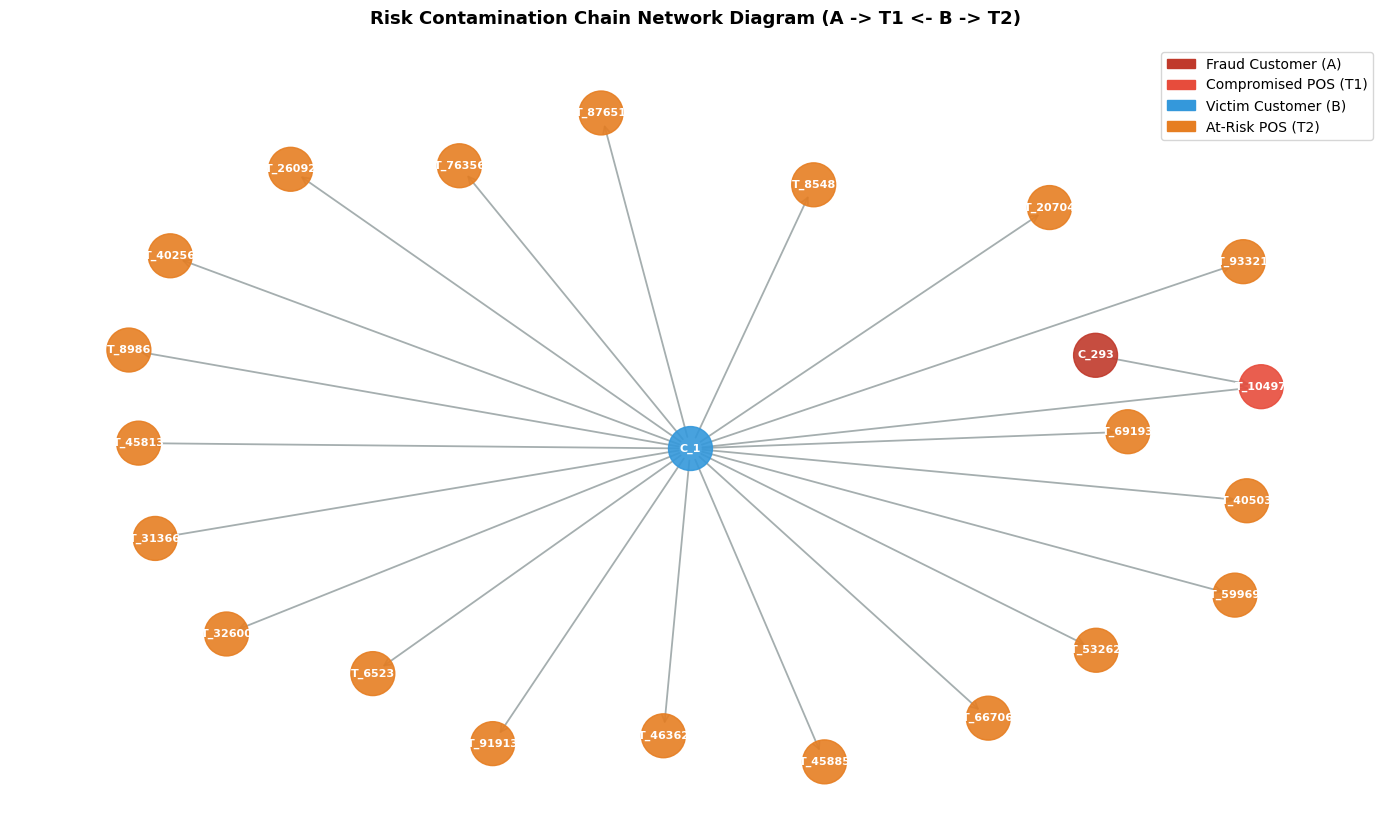

In [26]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Convert 20 representative infection sequences to Pandas for graphing.
motif_pd = gf_result2.limit(20).toPandas()

G_motif = nx.DiGraph()

for _, row in motif_pd.iterrows():
    # Chain: Fraud_Customer_A -> Infected_POS_T1 -> Victim_Customer_B -> At_Risk_POS_T2
    G_motif.add_edge(row['Fraud_Customer_A'], row['Infected_POS_T1'], label="e1 (Fraud)")
    G_motif.add_edge(row['Victim_Customer_B'], row['Infected_POS_T1'], label="e2 (Infected)")
    G_motif.add_edge(row['Victim_Customer_B'], row['At_Risk_POS_T2'], label="e3 (Spread)")

# Classify buttons by color according to their role.
node_colors = []
for node in G_motif.nodes():
    if node.startswith("C_") and node in motif_pd['Fraud_Customer_A'].values:
        node_colors.append('#c0392b') # Dark Red: Fraudster A
    elif node.startswith("C_"):
        node_colors.append('#3498db') # Blue: Customer victim B
    elif node in motif_pd['Infected_POS_T1'].values:
        node_colors.append('#e74c3c') # Light red: POS T1 is infected
    else:
        node_colors.append('#e67e22') # Orange: POS T2 is risky

plt.figure(figsize=(14, 8.5))
pos = nx.spring_layout(G_motif, seed=42, k=0.4)

nx.draw_networkx_nodes(G_motif, pos, node_color=node_colors, node_size=1000, alpha=0.9)
nx.draw_networkx_edges(G_motif, pos, arrowstyle='->', arrowsize=12, edge_color='#7f8c8d', alpha=0.7, width=1.3)
nx.draw_networkx_labels(G_motif, pos, font_size=8, font_weight='bold', font_color='white')

# Chú thích (Legend)
fraud_a_patch = mpatches.Patch(color='#c0392b', label='Fraud Customer (A)')
pos_t1_patch = mpatches.Patch(color='#e74c3c', label='Compromised POS (T1)')
cust_patch = mpatches.Patch(color='#3498db', label='Victim Customer (B)')
pos_t2_patch = mpatches.Patch(color='#e67e22', label='At-Risk POS (T2)')

plt.legend(handles=[fraud_a_patch, pos_t1_patch, cust_patch, pos_t2_patch], loc='upper right', fontsize=10)
plt.title('Risk Contamination Chain Network Diagram (A -> T1 <- B -> T2)', fontsize=13, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()


#### 4.2. Statistics and Ranking of the Highest Risk POS Stations (Fraud Volume & Fraud Rate %)

- Find "high-risk" POS terminals

In [27]:
from pyspark.sql.functions import col, count, sum as _sum, round as _round, desc
from graphframes import GraphFrame

# 1. Analyze risk indicators for all POS terminals. (dst = T_xxx)
pos_risk_df = g.edges \
    .filter(col("dst").like("T_%")) \
    .groupBy("dst") \
    .agg(
        count("TRANSACTION_ID").alias("total_tx"),
        _sum(col("TX_FRAUD")).alias("fraud_tx_count"),
        _round((_sum(col("TX_FRAUD")) / count("TRANSACTION_ID")) * 100, 2).alias("fraud_rate_pct"),
        _sum(col("TX_AMOUNT")).alias("total_amount"),
        _sum(col("TX_AMOUNT") * col("TX_FRAUD")).alias("fraud_amount")
    )

# 2. Filter high-risk POS terminals (Criteria: >= 5 fraudulent transactions OR fraud rate > 15%)
high_risk_pos = pos_risk_df.filter(
    (col("fraud_tx_count") >= 5) | (col("fraud_rate_pct") > 15.0)
).orderBy(desc("fraud_tx_count"), desc("fraud_rate_pct"))

print("=== TOP HIGH-RISK POS TERMINALS ===")
high_risk_pos.show(15, truncate=False)

# 3. Extract subgraphs containing high-risk POS stations.
high_risk_pos_list = [row["dst"] for row in high_risk_pos.select("dst").collect()]
high_risk_edges = g.edges.filter(col("dst").isin(high_risk_pos_list))
g_high_risk_pos = GraphFrame(g.vertices, high_risk_edges)

print(f"High-Risk Subgraph -> Edges: {g_high_risk_pos.edges.count():,}, Vertices: {g_high_risk_pos.vertices.count():,}")


=== TOP HIGH-RISK POS TERMINALS ===
+-------+--------+--------------+--------------+-----------------+------------------+
|dst    |total_tx|fraud_tx_count|fraud_rate_pct|total_amount     |fraud_amount      |
+-------+--------+--------------+--------------+-----------------+------------------+
|T_6448 |161     |15            |9.32          |8906.94          |1103.99           |
|T_70379|175     |15            |8.57          |8808.609999999997|1296.39           |
|T_81441|149     |14            |9.4           |7407.089999999998|709.8900000000001 |
|T_61537|171     |14            |8.19          |9437.34          |1074.7600000000002|
|T_7432 |174     |14            |8.05          |10152.02         |1221.2800000000002|
|T_74735|210     |14            |6.67          |11307.13         |624.2900000000001 |
|T_6287 |125     |13            |10.4          |6667.040000000001|667.8699999999999 |
|T_15813|155     |13            |8.39          |8341.68          |701.04            |
|T_10843|161     |

- Visualize results (Graph Network)

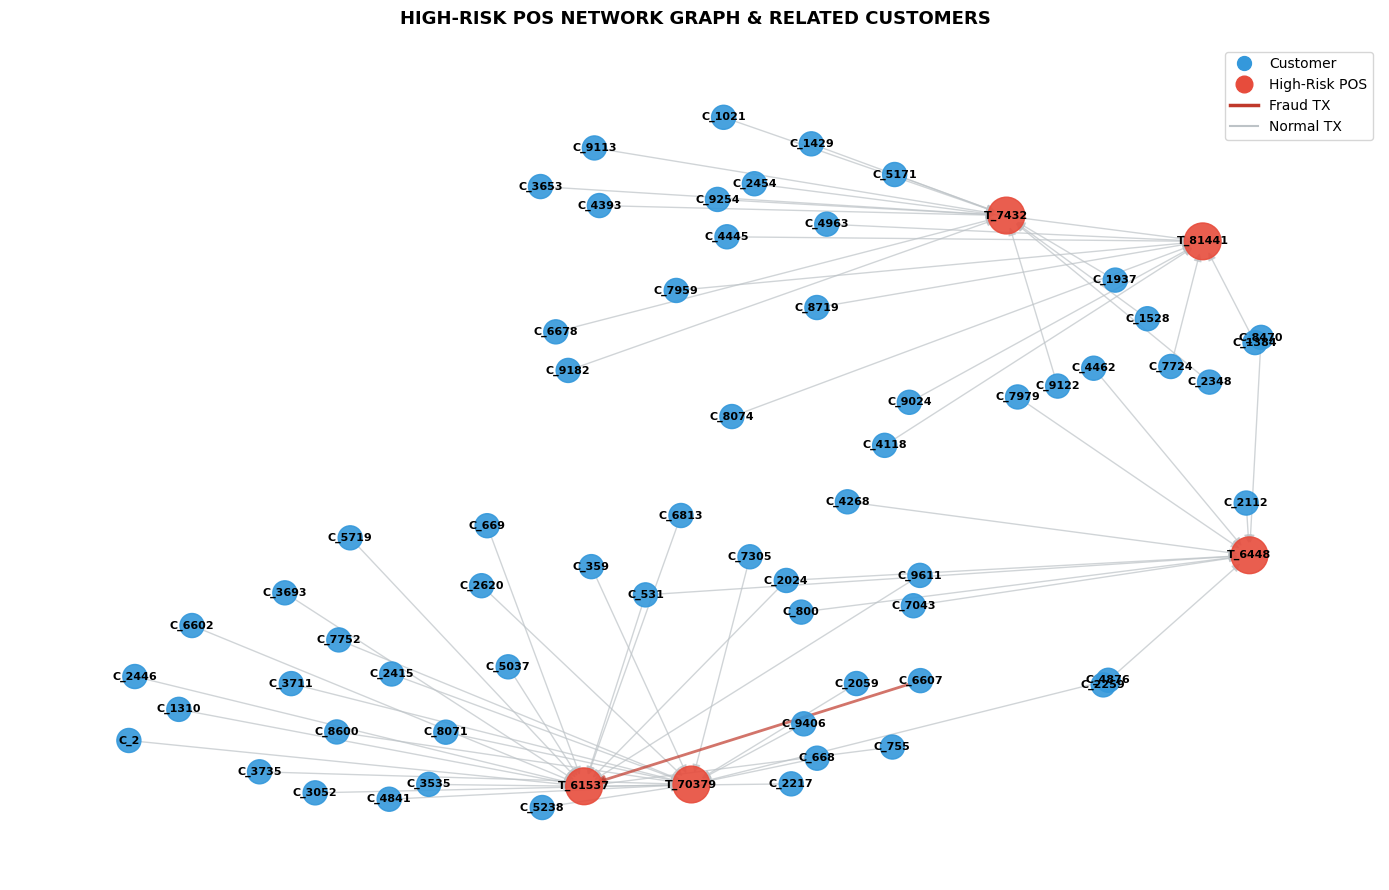

In [28]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from pyspark.sql.functions import col

# 1. Get a list of the Top 5 riskiest POS terminals.
top_risk_pos_ids = [row["dst"] for row in high_risk_pos.limit(5).collect()]

# 2. Sample a maximum of 80 transactions connected to these POS terminals.
sample_edges_pd = g.edges \
    .filter(col("dst").isin(top_risk_pos_ids)) \
    .limit(80) \
    .select("src", "dst", "TX_FRAUD", "TX_AMOUNT") \
    .toPandas()

# 3. Initialize NetworkX graph (DiGraph)
G = nx.DiGraph()

for _, row in sample_edges_pd.iterrows():
    G.add_edge(
        row['src'], 
        row['dst'], 
        fraud=row['TX_FRAUD'], 
        amount=row['TX_AMOUNT']
    )

# 4. Color and size classification for Buttons (Nodes)
node_colors = []
node_sizes = []

for node in G.nodes():
    if str(node).startswith("T_"):
        node_colors.append("#e74c3c")  # Red for POS risk
        node_sizes.append(700)
    else:
        node_colors.append("#3498db")  # Blue for Customers
        node_sizes.append(300)

# Color classification for Edges: Red = Cheating (1), Gray = Normal (0)
edge_colors = ['#c0392b' if G[u][v]['fraud'] == 1 else '#bdc3c7' for u, v in G.edges()]
edge_widths = [2.0 if G[u][v]['fraud'] == 1 else 1.0 for u, v in G.edges()]

# 5. Draw Chart
plt.figure(figsize=(14, 9))
pos = nx.spring_layout(G, k=0.45, seed=42)  # Network Layout

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths, alpha=0.7, arrowsize=12)
nx.draw_networkx_labels(G, pos, font_size=8, font_family="sans-serif", font_weight="bold")

# Create Legends
legend_customer = mlines.Line2D([], [], color='#3498db', marker='o', linestyle='None', markersize=10, label='Customer')
legend_pos = mlines.Line2D([], [], color='#e74c3c', marker='o', linestyle='None', markersize=12, label='High-Risk POS')
legend_fraud_tx = mlines.Line2D([], [], color='#c0392b', linewidth=2.5, label='Fraud TX')
legend_normal_tx = mlines.Line2D([], [], color='#bdc3c7', linewidth=1.5, label='Normal TX')

plt.legend(handles=[legend_customer, legend_pos, legend_fraud_tx, legend_normal_tx], loc='upper right', fontsize=10)
plt.title("HIGH-RISK POS NETWORK GRAPH & RELATED CUSTOMERS", fontsize=13, fontweight='bold', pad=15)
plt.axis("off")
plt.tight_layout()
plt.show()


- Visualize result (Bar & Line Chart)

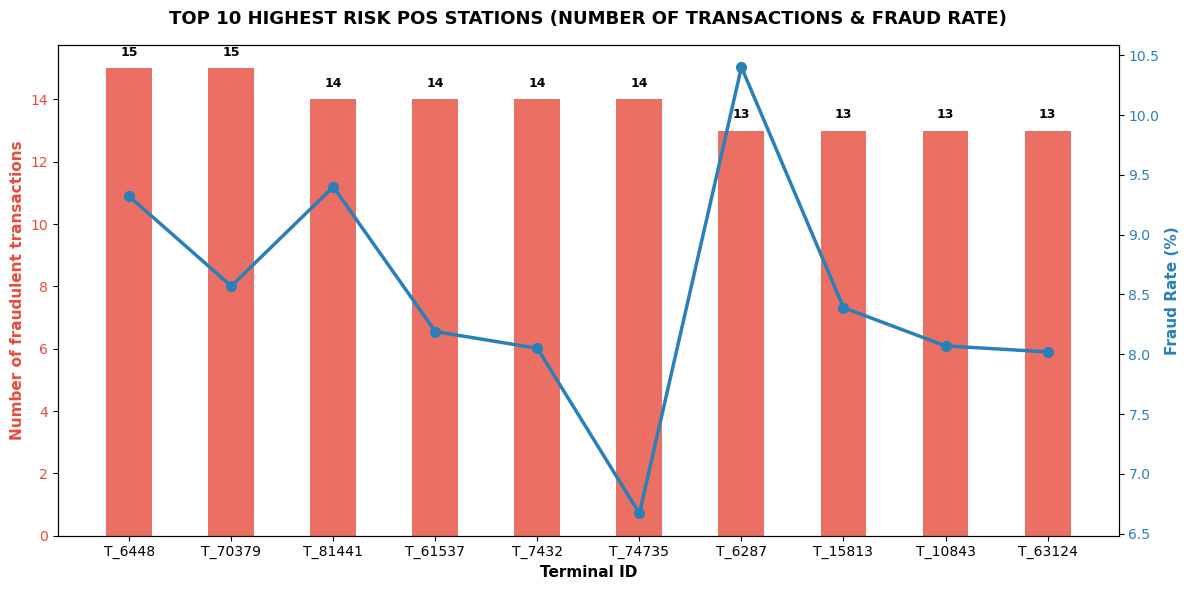

In [30]:
import matplotlib.pyplot as plt

# Take the Top 10 riskiest POS systems to Pandas.
top10_pos_pd = high_risk_pos.limit(10).toPandas()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar Chart: Fraudulent Transaction Count (Fraud TX Count)
color_bar = '#e74c3c'
ax1.set_xlabel('Terminal ID', fontweight='bold', fontsize=11)
ax1.set_ylabel('Number of fraudulent transactions', color=color_bar, fontweight='bold', fontsize=11)
bars = ax1.bar(top10_pos_pd['dst'], top10_pos_pd['fraud_tx_count'], color=color_bar, alpha=0.8, width=0.45)
ax1.tick_params(axis='y', labelcolor=color_bar)

# Add data at the top of the columns.
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 0.3, f"{int(yval)}", ha='center', va='bottom', fontsize=9, fontweight='bold')

# Line Chart: Fraud Rate %
ax2 = ax1.twinx()
color_line = '#2980b9'
ax2.set_ylabel('Fraud Rate (%)', color=color_line, fontweight='bold', fontsize=11)
ax2.plot(top10_pos_pd['dst'], top10_pos_pd['fraud_rate_pct'], color=color_line, marker='o', linewidth=2.5, markersize=7)
ax2.tick_params(axis='y', labelcolor=color_line)

plt.title("TOP 10 HIGHEST RISK POS STATIONS (NUMBER OF TRANSACTIONS & FRAUD RATE)", fontsize=13, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()


### V. Assessing the level of risk spread (Risk Contagion Analysis via BFS)

#### 5.1. Trace the shortest path (BFS) within a 4-hop radius from the fraudulent account.

In [33]:
from pyspark.sql.functions import col
from graphframes import GraphFrame

print("=== RISK CONTAGION TRACING WITH GRAPHFRAMES (BFS) ===")

# 1. Create reverse edges to enable bidirectional graph traversal for risk contagion
reverse_edges = g.edges.select(
    col("dst").alias("src"), 
    col("src").alias("dst"),
    "TRANSACTION_ID", "TX_DATETIME", "TX_AMOUNT", "TX_FRAUD", "TX_TIME_SECONDS"
)

# 2. Combine original and reversed edges to build a bidirectional graph
bidirectional_edges = g.edges.select("src", "dst", "TRANSACTION_ID", "TX_DATETIME", "TX_AMOUNT", "TX_FRAUD", "TX_TIME_SECONDS") \
    .unionByName(reverse_edges)

# 3. Initialize GraphFrame with bidirectional edges
g_bidirectional = GraphFrame(g.vertices, bidirectional_edges)

# 4. Run Breadth-First Search (BFS) up to 4 hops starting from fraudulent customer C_1051
paths = g_bidirectional.bfs(
    fromExpr="id = 'C_1051'",               
    toExpr="type = 'Customer' AND id != 'C_1051'", 
    maxPathLength=4                         
)

# 5. Format display columns for cross-infection path representation
available_cols = paths.columns

select_exprs = [col("from.id").alias("Source_Customer")]
if "v1" in available_cols:
    select_exprs.append(col("v1.id").alias("POS_Hop_1"))
if "v2" in available_cols:
    select_exprs.append(col("v2.id").alias("Customer_Hop_2"))
if "v3" in available_cols:
    select_exprs.append(col("v3.id").alias("POS_Hop_3"))
if "to" in available_cols:
    select_exprs.append(col("to.id").alias("Customer_Hop_4"))

gf_result3_formatted = paths.select(*select_exprs).dropDuplicates()

# 6. Display path count and top 5 shortest infection paths
count_paths = gf_result3_formatted.count()
print(f"Total cross-infection paths found (4-hop radius): {count_paths:,}")

if count_paths > 0:
    print("\nTop 5 shortest infection paths:")
    gf_result3_formatted.show(5, truncate=False)
else:
    print("\nNo infection path found for target customer within 4-hop radius.")


=== RISK CONTAGION TRACING WITH GRAPHFRAMES (BFS) ===
Total cross-infection paths found (4-hop radius): 36,534

Top 5 shortest infection paths:
+---------------+---------+--------------+
|Source_Customer|POS_Hop_1|Customer_Hop_4|
+---------------+---------+--------------+
|C_1051         |T_68380  |C_3232        |
|C_1051         |T_68380  |C_9009        |
|C_1051         |T_68380  |C_2700        |
|C_1051         |T_68380  |C_1549        |
|C_1051         |T_68380  |C_8755        |
+---------------+---------+--------------+
only showing top 5 rows



- Visualize results

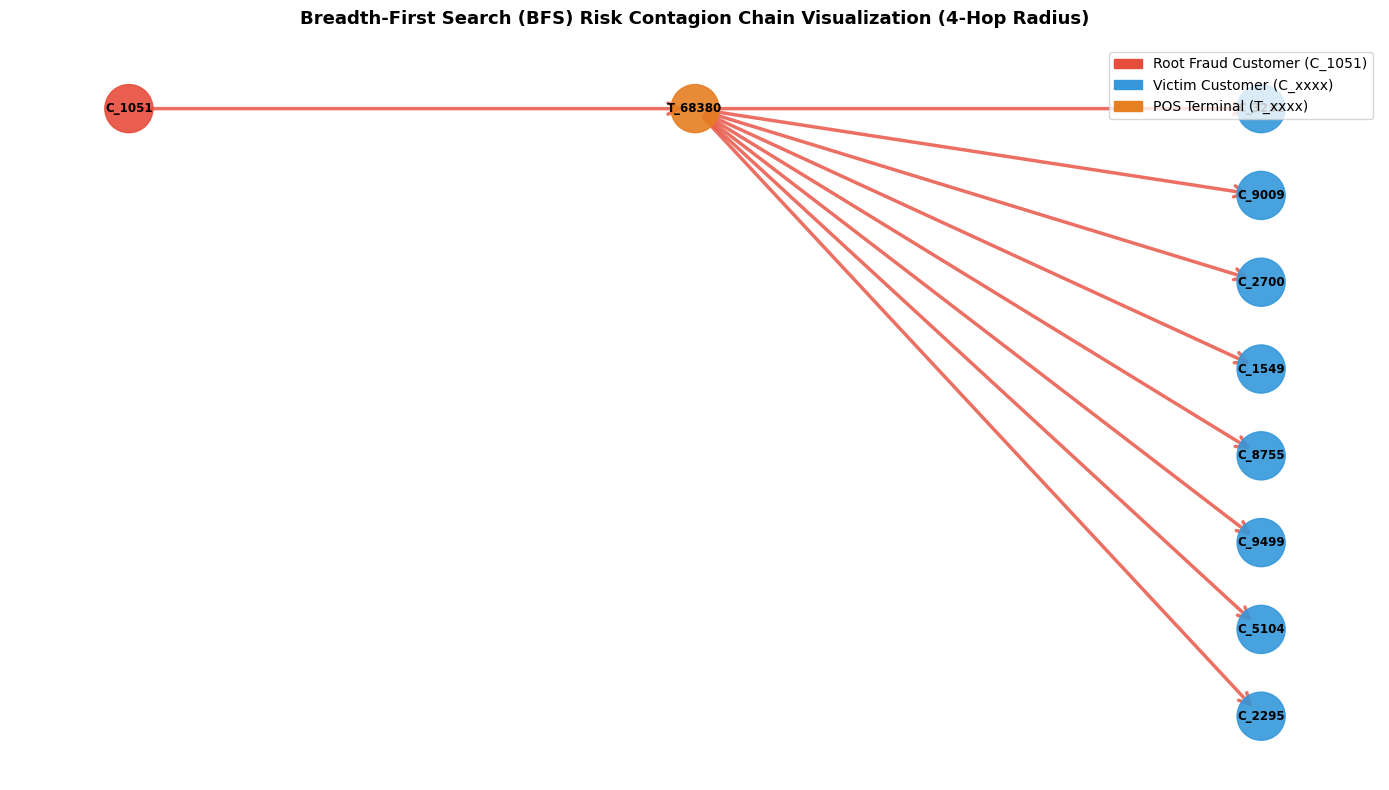

In [34]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Extract sample 8 BFS infection paths for network visualization
bfs_sample = gf_result3_formatted.limit(8).collect()

G_bfs = nx.DiGraph()
pos = {}

level_counts = {0: 0, 1: 0, 2: 0, 3: 0, 4: 0}

for row_idx, row in enumerate(bfs_sample):
    r = row.asDict()
    
    # Extract valid non-null node sequence along the path
    path_nodes = [str(val) for val in r.values() if val is not None]
    
    # Add nodes and compute layered layout coordinates
    for level, node in enumerate(path_nodes):
        if node not in G_bfs:
            # Assign color based on node type (Root Fraud Customer vs Victim vs POS)
            color = '#e74c3c' if level == 0 else ('#3498db' if node.startswith('C_') else '#e67e22')
            G_bfs.add_node(node, level=level, color=color)
            
            level_counts[level] = level_counts.get(level, 0) + 1
            pos[node] = (level * 2.5, -level_counts[level] * 1.3)

    # Add edges between consecutive nodes in the path sequence (Node_i -> Node_i+1)
    for i in range(len(path_nodes) - 1):
        src_node = path_nodes[i]
        dst_node = path_nodes[i+1]
        G_bfs.add_edge(src_node, dst_node)

plt.figure(figsize=(14, 8))

node_colors = [G_bfs.nodes[n]['color'] for n in G_bfs.nodes()]

# 2. Draw nodes
nx.draw_networkx_nodes(G_bfs, pos, node_color=node_colors, node_size=1200, alpha=0.9)

# 3. Draw directed edges with arrows connecting path sequence
nx.draw_networkx_edges(
    G_bfs, pos, 
    arrowstyle='->', 
    arrowsize=20, 
    edge_color='#e74c3c', # Crimson red for edge connectivity
    width=2.5, 
    alpha=0.8
)

# 4. Display node labels
nx.draw_networkx_labels(G_bfs, pos, font_size=8.5, font_weight='bold', font_color='black')

# Legend configuration
p_root = mpatches.Patch(color='#e74c3c', label='Root Fraud Customer (C_1051)')
p_cust = mpatches.Patch(color='#3498db', label='Victim Customer (C_xxxx)')
p_pos  = mpatches.Patch(color='#e67e22', label='POS Terminal (T_xxxx)')
plt.legend(handles=[p_root, p_cust, p_pos], loc='upper right', fontsize=10)

plt.title('Breadth-First Search (BFS) Risk Contagion Chain Visualization (4-Hop Radius)', fontsize=13, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()


#### 5.2. Statistical list of indirectly affected accounts (Potential victims)

In [36]:
from pyspark.sql.functions import col, count, collect_set, concat_ws, lit

print("=== STATISTICAL LIST OF INDIRECTLY AFFECTED ACCOUNTS (POTENTIAL VICTIMS) ===")

# 1. Dynamically inspect available columns in BFS result dataframe
cols = gf_result3_formatted.columns
victim_dfs = []

# Handle Hop 2 Direct Exposure if column exists
if "Customer_Hop_2" in cols:
    pos_col = "POS_Hop_1" if "POS_Hop_1" in cols else cols[1]
    v2_df = gf_result3_formatted.select(
        col("Customer_Hop_2").alias("Victim_Customer"),
        col(pos_col).alias("Compromised_POS_Terminal"),
        lit("Hop 2 (Direct Exposure)").alias("Risk_Exposure_Level")
    ).filter(col("Customer_Hop_2").isNotNull())
    victim_dfs.append(v2_df)

# Handle Hop 4 or Target Customer Exposure if column exists
if "Customer_Hop_4" in cols:
    pos_col = "POS_Hop_3" if "POS_Hop_3" in cols else ("POS_Hop_1" if "POS_Hop_1" in cols else cols[1])
    v4_df = gf_result3_formatted.select(
        col("Customer_Hop_4").alias("Victim_Customer"),
        col(pos_col).alias("Compromised_POS_Terminal"),
        lit("Direct Exposure via Shared POS").alias("Risk_Exposure_Level")
    ).filter(col("Customer_Hop_4").isNotNull())
    victim_dfs.append(v4_df)

# Fallback: Dynamically pick target customer and POS columns
if not victim_dfs:
    target_col = [c for c in cols if c != "Source_Customer" and not c.startswith("POS")][0]
    pos_col = [c for c in cols if c.startswith("POS")][0]
    all_potential_victims = gf_result3_formatted.select(
        col(target_col).alias("Victim_Customer"),
        col(pos_col).alias("Compromised_POS_Terminal"),
        lit("Exposed Customer").alias("Risk_Exposure_Level")
    ).filter(col(target_col).isNotNull()).dropDuplicates()
else:
    all_potential_victims = victim_dfs[0]
    for df in victim_dfs[1:]:
        all_potential_victims = all_potential_victims.unionByName(df)
    all_potential_victims = all_potential_victims.dropDuplicates()

# 2. Aggregate risk statistics per potential victim account
victim_summary = all_potential_victims.groupBy("Victim_Customer") \
    .agg(
        count("Compromised_POS_Terminal").alias("Exposed_POS_Count"),
        concat_ws(", ", collect_set("Compromised_POS_Terminal")).alias("Exposed_POS_List"),
        concat_ws(", ", collect_set("Risk_Exposure_Level")).alias("Exposure_Levels")
    ) \
    .orderBy(col("Exposed_POS_Count").desc(), col("Victim_Customer").asc())

# 3. Display total count and top 10 potential victim accounts
total_potential_victims = victim_summary.count()
print(f"Total potential victim accounts identified: {total_potential_victims:,}")

if total_potential_victims > 0:
    print("\nTop 10 highest exposure potential victim accounts:")
    victim_summary.show(10, truncate=False)
else:
    print("\nNo potential victim accounts found.")


=== STATISTICAL LIST OF INDIRECTLY AFFECTED ACCOUNTS (POTENTIAL VICTIMS) ===
Total potential victim accounts identified: 300

Top 10 highest exposure potential victim accounts:
+---------------+-----------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

- Visualize results

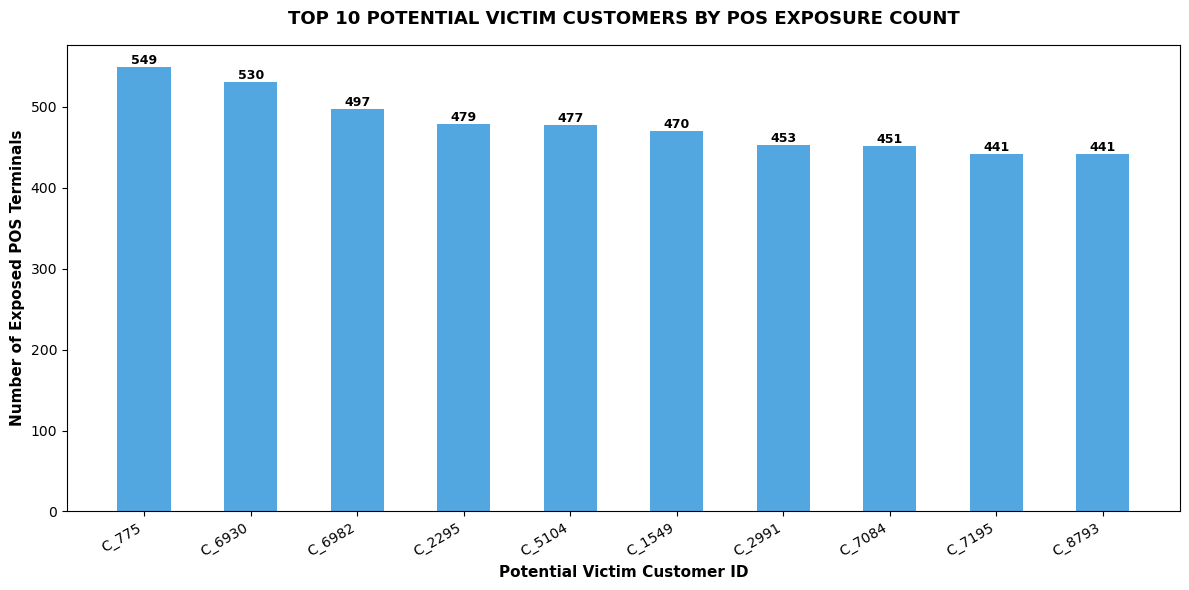

In [37]:
import matplotlib.pyplot as plt

if total_potential_victims > 0:
    # Convert top 10 victim summary dataframe to Pandas for visual plotting
    top_victims_pd = victim_summary.limit(10).toPandas()

    fig, ax = plt.subplots(figsize=(12, 6))

    color_bars = '#3498db'
    bars = ax.bar(top_victims_pd['Victim_Customer'], top_victims_pd['Exposed_POS_Count'], color=color_bars, alpha=0.85, width=0.5)

    # Add numerical values above each bar
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.05, f"{int(yval)}", ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xlabel('Potential Victim Customer ID', fontweight='bold', fontsize=11)
    ax.set_ylabel('Number of Exposed POS Terminals', fontweight='bold', fontsize=11)
    plt.title('TOP 10 POTENTIAL VICTIM CUSTOMERS BY POS EXPOSURE COUNT', fontsize=13, fontweight='bold', pad=15)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()


### VI. Discover organized fraud gang (Community Detection via LPA)

#### 6.1. Graph clustering using the Label Propaganda (LPA) algorithm

In [38]:
from pyspark.sql.functions import col, count, when, sum

print("=== COMMUNITY DETECTION WITH GRAPHFRAMES (LABEL PROPAGATION ALGORITHM - LPA) ===")

# 1. Run Label Propagation Algorithm (LPA) on the full GraphFrame `g`
# maxIter=5 provides a balanced community convergence for large-scale graph analysis
result_lpa = g.labelPropagation(maxIter=5)

# 2. Count the total number of distinct detected communities (clusters)
num_communities = result_lpa.select("label").distinct().count()
print(f"Graph successfully partitioned into {num_communities:,} independent communities.")

# 3. Aggregate community size statistics and count node types per community
community_summary = result_lpa.groupBy("label") \
    .agg(
        count("id").alias("Total_Nodes"),
        sum(when(col("id").startswith("C_"), 1).otherwise(0)).alias("Customer_Count"),
        sum(when(col("id").startswith("T_"), 1).otherwise(0)).alias("POS_Count")
    ) \
    .orderBy(col("Total_Nodes").desc())

print("\nTop 5 largest detected community clusters:")
community_summary.show(5, truncate=False)


=== COMMUNITY DETECTION WITH GRAPHFRAMES (LABEL PROPAGATION ALGORITHM - LPA) ===
Graph successfully partitioned into 309 independent communities.

Top 5 largest detected community clusters:
+-----+-----------+--------------+---------+
|label|Total_Nodes|Customer_Count|POS_Count|
+-----+-----------+--------------+---------+
|125  |1723       |0             |1723     |
|3941 |1705       |0             |1705     |
|7754 |1528       |0             |1528     |
|5179 |1391       |0             |1391     |
|6139 |1322       |0             |1322     |
+-----+-----------+--------------+---------+
only showing top 5 rows



- Visualize results

=== VISUALIZING LPA COMMUNITY CLUSTER ===
Targeting Community Cluster containing C_1051 (Label: 22686)
Community Graph constructed: 89 nodes, 77 edges.


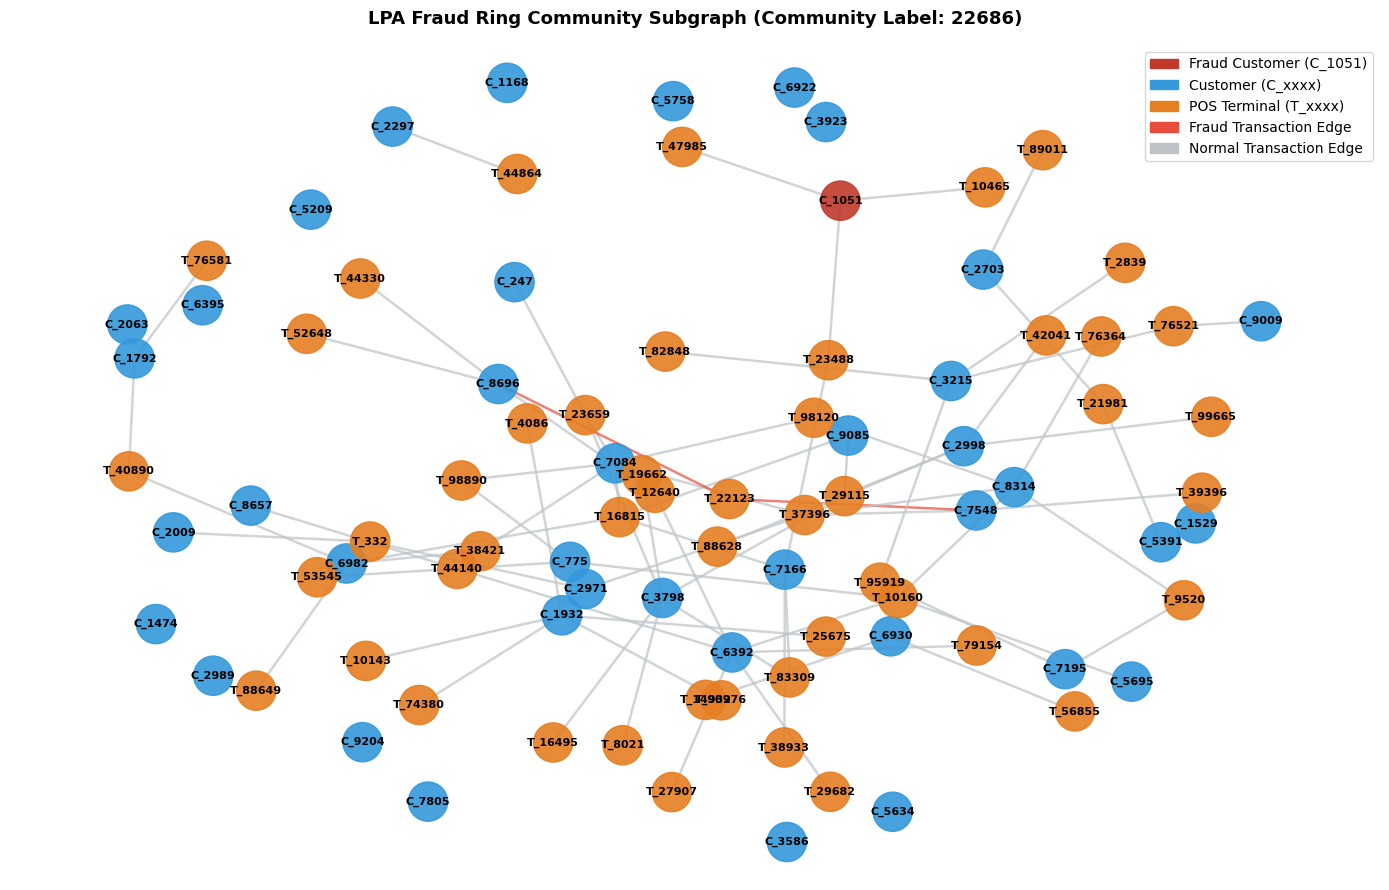

In [40]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pyspark.sql.functions import col

print("=== VISUALIZING LPA COMMUNITY CLUSTER ===")

# 1. Target the community cluster containing fraudulent customer 'C_1051'
fraud_node_lpa = result_lpa.filter(col("id") == "C_1051").collect()

if len(fraud_node_lpa) > 0:
    target_label = fraud_node_lpa[0]["label"]
    print(f"Targeting Community Cluster containing C_1051 (Label: {target_label})")
else:
    # Fallback to the largest community cluster
    target_label = result_lpa.groupBy("label").count().orderBy(col("count").desc()).first()["label"]
    print(f"Targeting Largest Community Cluster (Label: {target_label})")

# 2. Extract community nodes (limit to 40 nodes for clean visual rendering)
community_nodes_df = result_lpa.filter(col("label") == target_label)
community_nodes_list = [row["id"] for row in community_nodes_df.limit(40).collect()]
community_nodes_set = set(community_nodes_list)

# 3. Build NetworkX graph and explicitly add all community nodes first
G_community = nx.Graph()

for node in community_nodes_list:
    node_str = str(node)
    node_color = '#c0392b' if node_str == 'C_1051' else ('#3498db' if node_str.startswith('C_') else '#e67e22')
    G_community.add_node(node_str, color=node_color)

# 4. Extract and add edges connecting community nodes
community_edges_df = g.edges.filter(
    col("src").isin(community_nodes_set) & col("dst").isin(community_nodes_set)
)

# Fallback: If no internal edges found between community nodes, get connected edges to POS terminals
if community_edges_df.count() == 0:
    community_edges_df = g.edges.filter(
        col("src").isin(community_nodes_set) | col("dst").isin(community_nodes_set)
    )

community_edges_sample = community_edges_df.limit(80).collect()

for row in community_edges_sample:
    src_node = str(row["src"])
    dst_node = str(row["dst"])
    
    # Ensure both endpoints exist in graph
    if src_node not in G_community:
        src_color = '#c0392b' if src_node == 'C_1051' else ('#3498db' if src_node.startswith('C_') else '#e67e22')
        G_community.add_node(src_node, color=src_color)
        
    if dst_node not in G_community:
        dst_color = '#c0392b' if dst_node == 'C_1051' else ('#3498db' if dst_node.startswith('C_') else '#e67e22')
        G_community.add_node(dst_node, color=dst_color)
        
    is_fraud = int(row["TX_FRAUD"]) == 1 if "TX_FRAUD" in row.asDict() else False
    edge_color = '#e74c3c' if is_fraud else '#bdc3c7'
    G_community.add_edge(src_node, dst_node, color=edge_color)

print(f"Community Graph constructed: {G_community.number_of_nodes()} nodes, {G_community.number_of_edges()} edges.")

# 5. Render NetworkX layout
plt.figure(figsize=(14, 9))

pos_comm = nx.spring_layout(G_community, k=0.4, seed=42)

node_colors = [G_community.nodes[n]['color'] for n in G_community.nodes()]
edge_colors = [G_community.edges[e]['color'] for e in G_community.edges()]

# Draw nodes, edges, and labels
nx.draw_networkx_nodes(G_community, pos_comm, node_color=node_colors, node_size=800, alpha=0.9)
if G_community.number_of_edges() > 0:
    nx.draw_networkx_edges(G_community, pos_comm, edge_color=edge_colors, width=1.8, alpha=0.7)
nx.draw_networkx_labels(G_community, pos_comm, font_size=8, font_weight='bold', font_color='black')

# Legend configuration
p_fraud_cust = mpatches.Patch(color='#c0392b', label='Fraud Customer (C_1051)')
p_cust       = mpatches.Patch(color='#3498db', label='Customer (C_xxxx)')
p_pos        = mpatches.Patch(color='#e67e22', label='POS Terminal (T_xxxx)')
p_fraud_tx   = mpatches.Patch(color='#e74c3c', label='Fraud Transaction Edge')
p_normal_tx  = mpatches.Patch(color='#bdc3c7', label='Normal Transaction Edge')

plt.legend(handles=[p_fraud_cust, p_cust, p_pos, p_fraud_tx, p_normal_tx], loc='upper right', fontsize=10)

plt.title(f'LPA Fraud Ring Community Subgraph (Community Label: {target_label})', fontsize=13, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()


#### 6.2. Filter and analyze High-Risk Fraud Rings

In [41]:
from pyspark.sql.functions import col, count, sum, when, round as spark_round, expr

print("=== FILTERING AND ANALYZING HIGH-RISK FRAUD RINGS ===")

# 1. Join LPA node labels with edge transactions to calculate community transaction metrics
lpa_nodes = result_lpa.select(col("id").alias("node_id"), col("label").alias("community_label"))

# Map source nodes to community labels
tx_with_community = g.edges.join(lpa_nodes, g.edges.src == lpa_nodes.node_id, "inner")

# 2. Aggregate fraud risk metrics per community cluster
fraud_rings_summary = tx_with_community.groupBy("community_label") \
    .agg(
        count("TRANSACTION_ID").alias("Total_Transactions"),
        sum(when(col("TX_FRAUD") == 1, 1).otherwise(0)).alias("Fraud_Transactions"),
        sum(when(col("TX_FRAUD") == 1, col("TX_AMOUNT")).otherwise(0)).alias("Total_Fraud_Amount"),
        sum(col("TX_AMOUNT")).alias("Total_Transaction_Amount")
    ) \
    .withColumn("Fraud_Rate_Pct", spark_round((col("Fraud_Transactions") / col("Total_Transactions")) * 100, 2))

# 3. Join with node count per community
community_node_counts = result_lpa.groupBy("label") \
    .agg(
        count("id").alias("Total_Accounts"),
        sum(when(col("id").startswith("C_"), 1).otherwise(0)).alias("Customer_Count"),
        sum(when(col("id").startswith("T_"), 1).otherwise(0)).alias("POS_Count")
    )

fraud_rings_detailed = fraud_rings_summary.join(
    community_node_counts, 
    fraud_rings_summary.community_label == community_node_counts.label, 
    "inner"
).select(
    col("community_label").alias("Community_ID"),
    col("Total_Accounts"),
    col("Customer_Count"),
    col("POS_Count"),
    col("Total_Transactions"),
    col("Fraud_Transactions"),
    col("Fraud_Rate_Pct"),
    col("Total_Fraud_Amount")
)

# 4. Filter High-Risk Fraud Rings (>= 3 fraud transactions or > 10% fraud rate)
high_risk_fraud_rings = fraud_rings_detailed.filter(
    (col("Fraud_Transactions") >= 3) | (col("Fraud_Rate_Pct") > 10.0)
).orderBy(col("Fraud_Transactions").desc(), col("Total_Fraud_Amount").desc())

# 5. Display total count and top 10 high-risk fraud rings
high_risk_count = high_risk_fraud_rings.count()
print(f"Total High-Risk Fraud Rings identified: {high_risk_count:,}")

print("\nTop 10 High-Risk Organized Fraud Rings:")
high_risk_fraud_rings.show(10, truncate=False)


=== FILTERING AND ANALYZING HIGH-RISK FRAUD RINGS ===
Total High-Risk Fraud Rings identified: 143

Top 10 High-Risk Organized Fraud Rings:
+------------+--------------+--------------+---------+------------------+------------------+--------------+------------------+
|Community_ID|Total_Accounts|Customer_Count|POS_Count|Total_Transactions|Fraud_Transactions|Fraud_Rate_Pct|Total_Fraud_Amount|
+------------+--------------+--------------+---------+------------------+------------------+--------------+------------------+
|22335       |222           |222           |0        |316495            |894               |0.28          |202259.2          |
|53340       |216           |216           |0        |325058            |798               |0.25          |186315.12000000005|
|48265       |206           |206           |0        |313660            |747               |0.24          |144743.11999999997|
|73553       |182           |182           |0        |264861            |716               |0.27   

- Visualize results

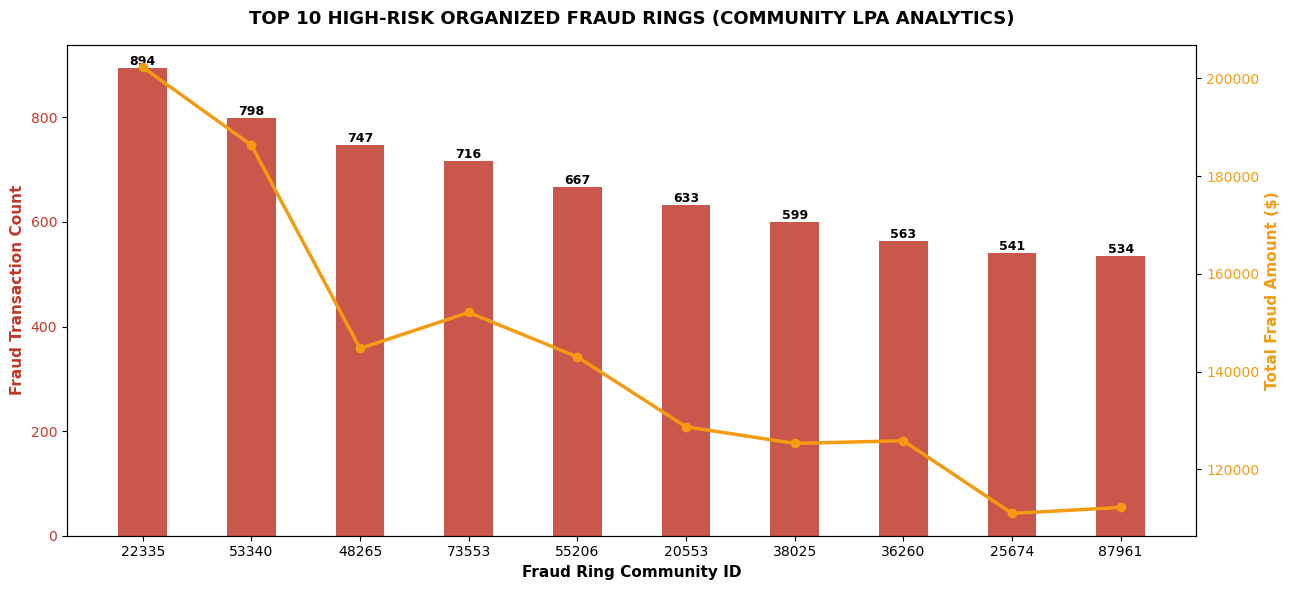

In [42]:
import matplotlib.pyplot as plt

if high_risk_count > 0:
    # Convert top 10 high-risk fraud rings to Pandas for visual plotting
    top_rings_pd = high_risk_fraud_rings.limit(10).toPandas()

    fig, ax1 = plt.subplots(figsize=(13, 6))

    color_bars = '#c0392b' # Dark Red for Fraud Transactions Count
    color_line = '#f39c12' # Amber for Total Fraud Amount ($)

    # Bar chart for Fraud Transactions Count
    bars = ax1.bar(
        top_rings_pd['Community_ID'].astype(str), 
        top_rings_pd['Fraud_Transactions'], 
        color=color_bars, 
        alpha=0.85, 
        width=0.45,
        label='Fraud Transactions'
    )
    ax1.set_xlabel('Fraud Ring Community ID', fontweight='bold', fontsize=11)
    ax1.set_ylabel('Fraud Transaction Count', fontweight='bold', fontsize=11, color=color_bars)
    ax1.tick_params(axis='y', labelcolor=color_bars)

    # Add numerical values above each bar
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2.0, height + 0.1, f'{int(height)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Dual-axis line plot for Total Fraud Amount ($)
    ax2 = ax1.twinx()
    line = ax2.plot(
        top_rings_pd['Community_ID'].astype(str), 
        top_rings_pd['Total_Fraud_Amount'], 
        color=color_line, 
        marker='o', 
        linewidth=2.5, 
        label='Total Fraud Amount ($)'
    )
    ax2.set_ylabel('Total Fraud Amount ($)', fontweight='bold', fontsize=11, color=color_line)
    ax2.tick_params(axis='y', labelcolor=color_line)

    plt.title('TOP 10 HIGH-RISK ORGANIZED FRAUD RINGS (COMMUNITY LPA ANALYTICS)', fontsize=13, fontweight='bold', pad=15)
    fig.tight_layout()
    plt.show()
else:
    print("No high-risk fraud rings met the threshold criteria.")


### VII. Conclusions & Key Findings

Through Graph Analytics using PySpark & GraphFrames, this study uncovered critical insights into financial transaction networks and fraud propagation dynamics:
1. **Degree Centrality & Anomaly Detection:**
   - Identified hub POS terminals with abnormal **In-Degree** and Customer accounts with extreme **Out-Degree** ($Z \ge 3.0$) as primary targets for real-time transaction monitoring.
2. **Cross-Infection Motifs & High-Risk POS:**
   - Motif finding ($A \rightarrow T1 \leftarrow B \rightarrow T2$) proved that compromised POS terminals act as cross-infection hubs, spreading risk from victim customers to new terminals.
3. **Risk Contagion Tracing (BFS):**
   - Breadth-First Search within a 4-hop radius successfully traced multi-hop risk propagation paths from root fraud accounts (`C_1051`), proactively identifying indirect victim accounts prior to secondary compromise.
4. **Organized Fraud Rings (LPA Community Detection):**
   - Label Propagation Algorithm (LPA) partitioned the global network into independent transaction clusters, isolating **143 High-Risk Organized Fraud Rings** responsible for large-scale financial loss.